# Laplace-Hamming Filter Example

- **By:** [Michael T. Kuczynski](https://www.linkedin.com/in/mkuczyns/), 2025 
- **License:** CC-BY 
- **How to cite:** Cite the ORMIR_XCT publication: *Kuczynski et al., (2024). ORMIR_XCT: A Python package for high resolution peripheral quantitative computed tomography image processing. Journal of Open Source Software, 9(97), 6084, https://doi.org/10.21105/joss.06084*

---
# Aims

- This Jupyter Notebook provides an example of running the Laplace-Hamming segmentation from the ORMIR_XCT package. 
- First, a Laplace-Hamming filter is applied to the image to smooth and enhance edges.
- Then, a global threshold is applied to segment the image.
- The input parameters to the Laplace-Hamming filter and segmentation are selected based on the paper by Sadoughi, et al. JBMR. 2023. https://doi.org/10.1002%2Fjbmr.4819. Specifically,
    - Laplace epsilon = 0.45
    - Laplace cut off frequency = 0.3
    - Hamming amplitude = 1.0
    - Lower threshold = 475 per mille

  **Table of contents**  
  [Step 1: Imports](#imports)   
  [Step 2: Laplace-Hamming Filter](#lh)  
  [Step 3: Global Threshold](#seg)  
  [Step 4: Compare to seg_gauss](#compare)


---

<a name="imports"></a>
## *Step 1: Imports:*

Import modules/packages and set the input image path. 

In [9]:
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

from ormir_xct.core.segmentation.seg_gauss import seg_gauss
from ormir_xct.core.segmentation.fft_laplace_hamming import fft_laplace_hamming

<a name="lh"></a>
## *Step 2: Laplace-Hamming Filter:*
Read in an image and run the Laplace-Hamming filter. Then, compare the filtered image to the original.

In [ ]:
# Read in an image
joint_seg_path = os.path.join("images", "GRAY_JOINT.nii")
output_path = "images"

gray_img = sitk.ReadImage(joint_seg_path, sitk.sitkFloat32)
gray_img_np = sitk.GetArrayFromImage(gray_img)

# Run the Laplace-Hamming filter
lh_image_np = fft_laplace_hamming(gray_img_np, laplace_epsilon=0.45, lp_cut_off_freq=0.3, hamming_amp=1.0)

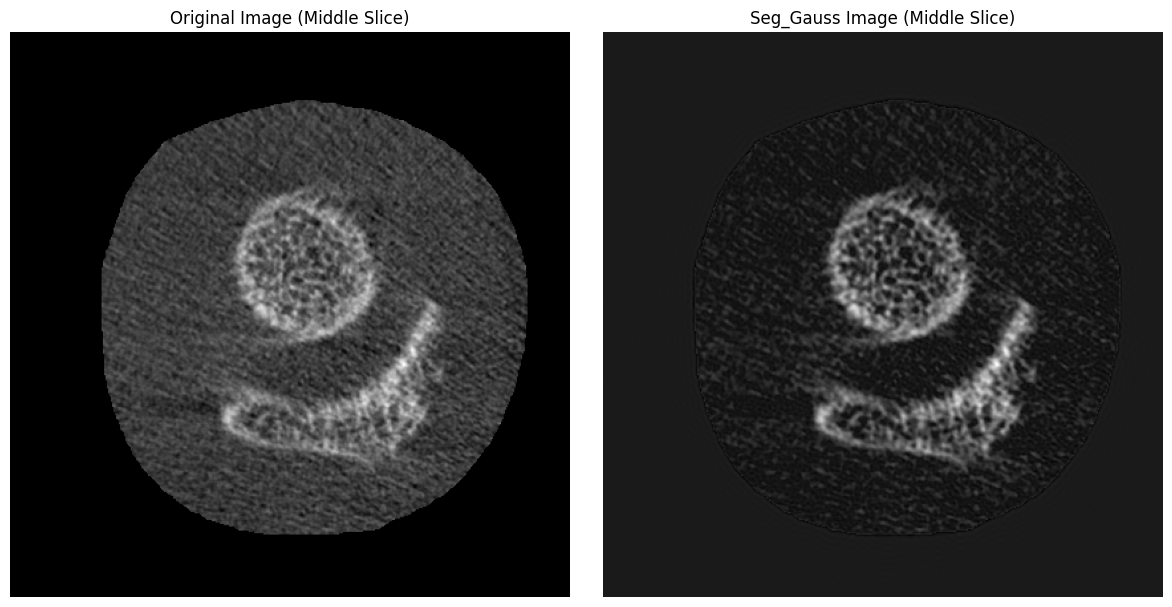

In [ ]:
slice_index = lh_image_np.shape[0] // 2

plt.figure(figsize=(12, 6))

# Plot the original image slice
plt.subplot(1, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.title("Original Image (Middle Slice)")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(1, 2, 2)
plt.imshow(lh_image_np[slice_index, :, :], cmap="gray")
plt.title("Laplace-Hamming Filtered Image (Middle Slice)")
plt.axis("off")

plt.tight_layout()
plt.show()

<a name="seg"></a>
## *Step 3: Global Threshold:*

Next, apply a global threshold of 475 per mille to the Laplace-Hamming filtered image. A Threshold of 475 per mille is 0.475 * the maximum intensity value of the image in native units. Since we are using a HR-pQCT (AIM) image that was converted to NIFTI using the ITKIOScanco module, our image is in HU. Assuming `mu_scaling = 8192`, `mu_water = 0.2396`, we can convert our image to per mille as follows:

1. Get the maximum intensity of the image in HU ($max_{HU}$)
$$
\mu = \frac{\text{max}_{HU} \cdot \mu_w}{1000} + \mu_w
$$

$$
\text{native} = \mu \times 8192
$$

$$
\text{threshold} = \text{native} \times 0.475
$$

$$
\text{threshold}_{HU} = 1000 \times \frac{\left(\frac{\text{threshold}}{8192} - \mu_w\right)}{\mu_w}
$$

Since the maximum of our test image is 3,828, our threshold is `1,293.3 HU`.

In [17]:
lh_image = sitk.GetImageFromArray(lh_image_np)
lh_image.CopyInformation(gray_img)

lh_seg = sitk.BinaryThreshold(lh_image, 1293, 10000, 1, 0)
lh_seg_np = sitk.GetArrayFromImage(lh_seg)

<a name="compare"></a>
## *Step 4: Compare to seg_gauss:*
Compare the Laplace-Hamming segmentation to the `seg_gauss` function.

In [16]:
ipl_mask = seg_gauss(gray_img, 1170, 10000, value_in_range=1, value_outside_range=0, 
                     sigma=0.8, support=1, use_image_spacing=False)
ipl_mask_np = sitk.GetArrayFromImage(ipl_mask)

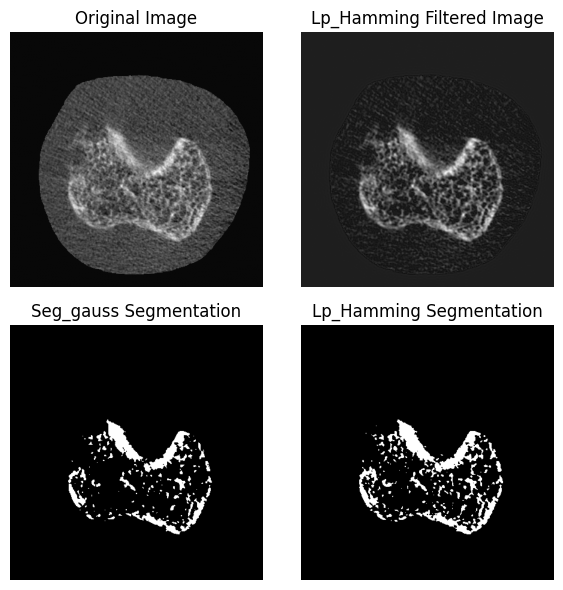

In [22]:
slice_index = (gray_img_np.shape[0] // 2)-25

plt.figure(figsize=(6, 6))

# Plot the original image slice
plt.subplot(2, 2, 1)
plt.imshow(gray_img_np[slice_index, :, :], cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Plot the seg_gauss image
plt.subplot(2, 2, 2)
plt.imshow(lh_image_np[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Filtered Image")
plt.axis("off")

# Plot the filtered image slice
plt.subplot(2, 2, 3)
plt.imshow(ipl_mask_np[slice_index, :, :], cmap="gray")
plt.title("Seg_gauss Segmentation")
plt.axis("off")

# Plot the seg of lp_hamming
plt.subplot(2, 2, 4)
plt.imshow(lh_seg_np[slice_index, :, :], cmap="gray")
plt.title("Lp_Hamming Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()

---
<a name="attribution"></a>

Notebook created using the [template](https://github.com/ORMIRcommunity/templates/blob/main/ORMIR_nb_template.ipynb) of the [ORMIR community](https://ormircommunity.github.io/) (version 1.0, 2023)